**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---


*   NOMBRE: Darío Martín Romero Cruz 
*   MATRÍCULA: A01841015

______________

*   NOMBRE: Erick Rojas Perez
*   MATRÍCULA: A01840850

______________

*   NOMBRE: Julio Arath Rosales Oliden 
*   MATRÍCULA: A01630378

______________

*   NOMBRE: Manuel Ruiz Diaz de Rivera
*   MATRÍCULA: A01325485

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [2]:
cars_df = pd.read_csv('automobile_dataset.csv', sep = ',') #Leer informacion

#Imprimir resultados
print('Tipos de datos de nuestro archivo:\n')
cars_df.info()

#Columnas numericas y categoricas
num_cols = cars_df.select_dtypes(include = np.number).columns
cat_cols = cars_df.select_dtypes(exclude = np.number).columns

print(f'\nColumnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')

# Identificar todas las columnas que contienen el símbolo '?'
cols_con_interrogacion = [c for c in cars_df.columns if (cars_df[c] == "?").any()]
print("Columnas con el símbolo '?':")
for c in cols_con_interrogacion:
    print(f"  - {c}: {(cars_df[c] == '?').sum()} registros")

#Reemplazar valores "?" por nan
cars_df[cat_cols] = cars_df[cat_cols].replace('?', np.nan)

# 3: Intentar convertir columnas objeto a numérico
for col in cat_cols:
    for dtype in ["Int64", "float64"]:
        try:
            cars_df[col] = cars_df[col].astype(dtype)
            break  # si funcionó, no intenta el siguiente
        except:
            continue

num_cols = cars_df.select_dtypes(include = np.number).columns
cat_cols = cars_df.select_dtypes(exclude = np.number).columns

print(f'\n  > Despues de cambio\nColumnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')

Tipos de datos de nuestro archivo:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int

**Comentario:**  
* El conjunto tiene **205 registros y 26 columnas**.
* Tras reemplazar `?` por `NaN` y convertirlas a numéricas, el conjunto queda con **17 columnas numéricas y 9 de texto (categóricas)**.

# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay registros duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

Registros duplicados: 0

Nulos por columna:
  > symboling: 0.0%
  > normalized_losses: 20.0%
  > make: 0.0%
  > fuel_type: 0.0%
  > aspiration: 0.0%
  > num_doors: 0.0%
  > body_style: 0.0%
  > drive_wheels: 0.0%
  > engine_location: 0.0%
  > wheel_base: 0.0%
  > length: 0.0%
  > width: 0.0%
  > height: 0.0%
  > curb_weight: 0.0%
  > engine_type: 0.0%
  > num_cylinders: 0.0%
  > engine_size: 0.0%
  > fuel_system: 0.0%
  > bore: 2.0%
  > stroke: 2.0%
  > compression_ratio: 0.0%
  > horsepower: 1.0%
  > peak_rpm: 1.0%
  > city_mpg: 0.0%
  > highway_mpg: 0.0%
  > price: 0.0%


ANALISIS DE LAS VARIABLES NUMERICAS:

Estadistica descriptiva

       symboling  normalized_losses  wheel_base  length   width  height  \
count     205.00              164.0      205.00  205.00  205.00  205.00   
mean        0.83              122.0       98.76  174.05   65.91   53.72   
std         1.25              35.44        6.02   12.34    2.15    2.44   
min        -2.00               65.0       86.60  141.10 

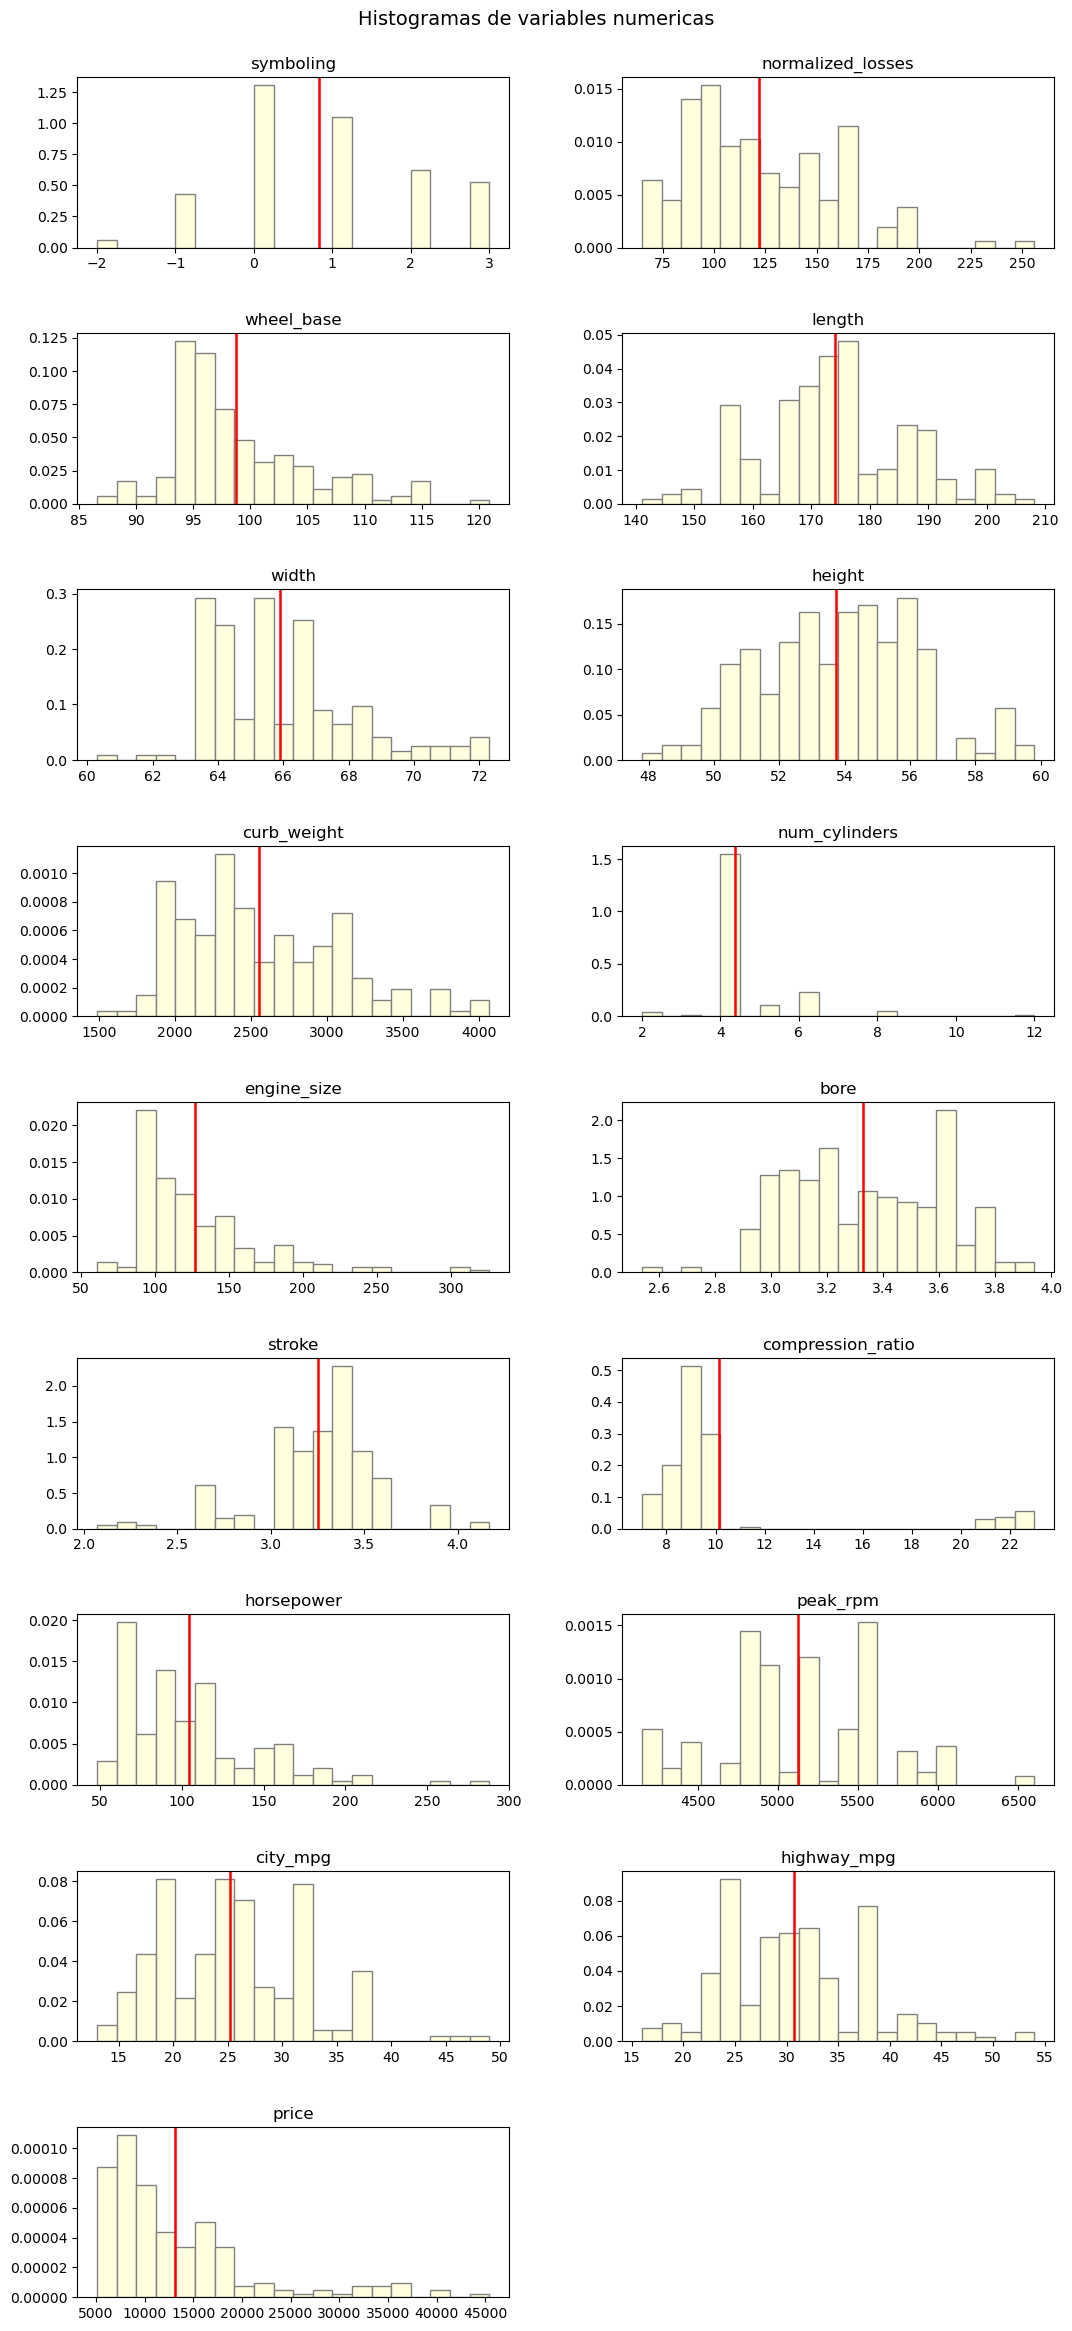



ANALISIS DE LAS VARIABLES CATEGORICAS:

Estadistica descriptiva

          make fuel_type aspiration num_doors body_style drive_wheels  \
count      205       205        205       205        205          205   
unique      22         2          2         2          5            3   
top     toyota       gas        std      four      sedan          fwd   
freq        32       185        168       116         96          120   

       engine_location engine_type fuel_system  
count              205         205         205  
unique               2           7           8  
top              front         ohc        mpfi  
freq               202         148          94  


Tablas de frecuencia

  > make
     toyota: 32
     nissan: 18
     mazda: 17
     mitsubishi: 13
     honda: 13
     volkswagen: 12
     subaru: 12
     peugot: 11
     volvo: 11
     dodge: 9
     mercedes-benz: 8
     bmw: 8
     audi: 7
     plymouth: 7
     saab: 6
     porsche: 5
     isuzu: 4
     jaguar: 3
    

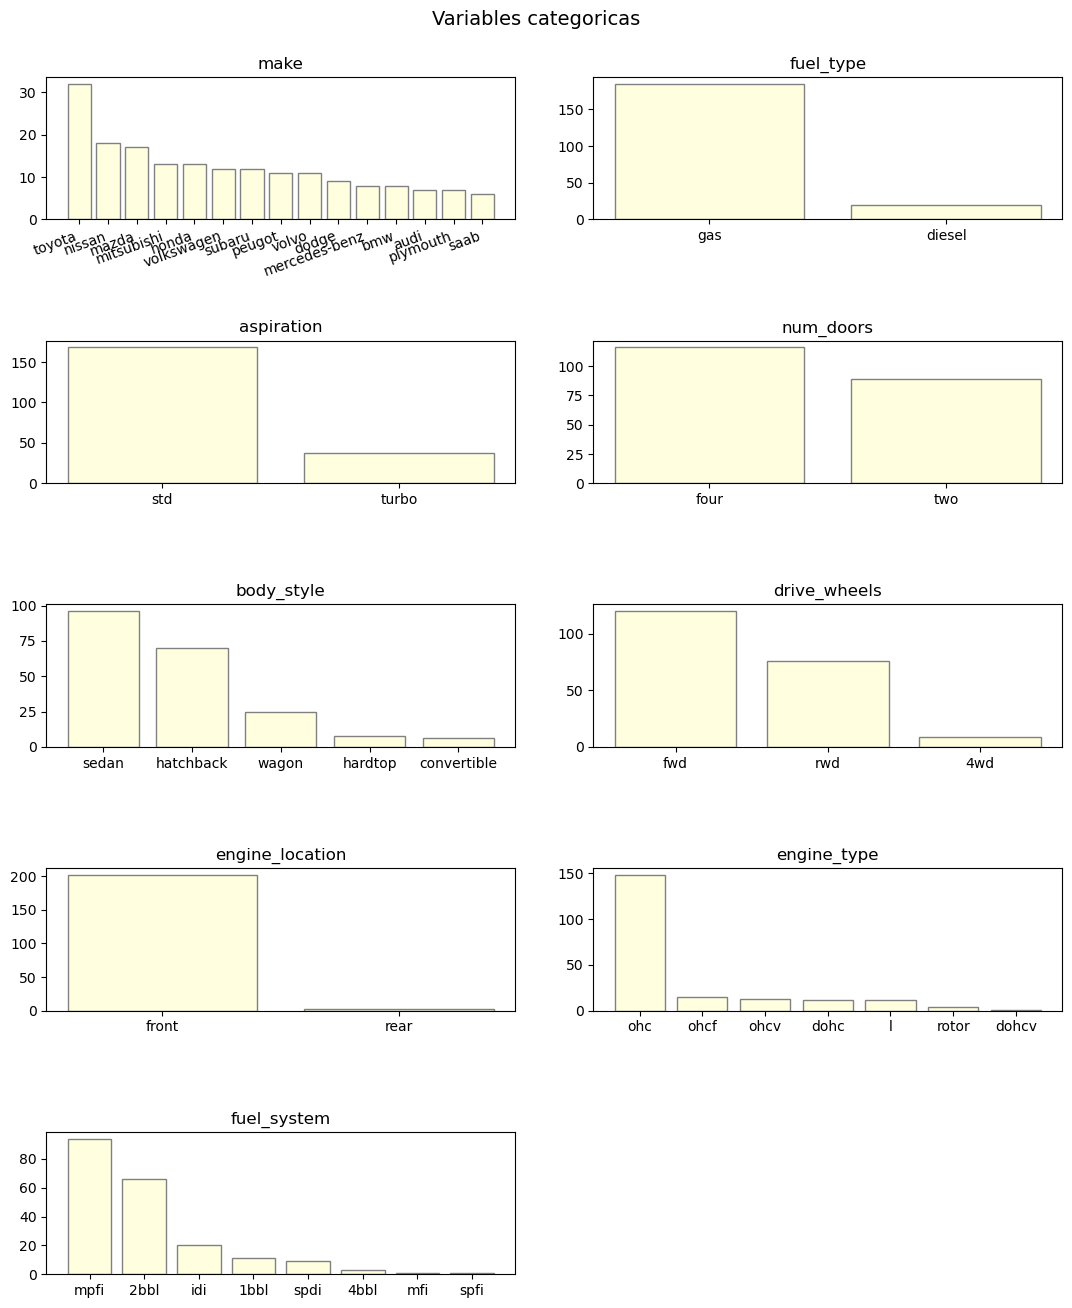

*Variables con mas de 15 categorias: make


In [3]:
#Revisar duplicados y nulos
print('Registros duplicados:', cars_df.duplicated().sum())

print('\nNulos por columna:')
for col, pct in cars_df.isna().mean().items():
    print(f'  > {col}: {pct:.1%}')


#Obtener estadísticas de las columnas numericas-------------
Stat1 = cars_df[num_cols].describe(percentiles = [0.05, 0.95])
Stat1 = pd.concat([Stat1, cars_df[num_cols].agg(['skew', 'kurt'])]) #Agregar sesgo y curtosis

#Imprimir resultados
print('\n\nANALISIS DE LAS VARIABLES NUMERICAS:\n\nEstadistica descriptiva\n')
print(Stat1.round(2))


#Histogramas-------------
print('\nHistogramas:')
Fig1 = plt.figure(figsize = (12, 25))
i = 0

for col in num_cols:
    i += 1
    Ax = Fig1.add_subplot(9, 2, i)

    #Histograma
    x = cars_df[col]
    Ax.hist(x, bins = 20, density = True, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    Ax.axvline(Stat1.loc['mean', col], color = 'red', ls = '-', lw = 1.8, label = 'Media') #Media
    Ax.set_title(col)

Fig1.suptitle('Histogramas de variables numericas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()


#Obtener estadísticas de las columnas categoricas-------------
cars_df[cat_cols] = cars_df[cat_cols].astype('category') #Pasa columnas tipo object a categoricas
Stat2 = cars_df[cat_cols].describe()

#Imprimir resultados
print('\n\nANALISIS DE LAS VARIABLES CATEGORICAS:\n\nEstadistica descriptiva\n')
print(Stat2.round(2))


#Tablas de frecuencia-------------
print('\n\nTablas de frecuencia')
for col in cat_cols:
    print(f'\n  > {col}')
    for val, count in cars_df[col].value_counts(dropna = False).items():
        print(f'     {val}: {count}')


#Graficas de barra-------------
Fig2 = plt.figure(figsize = (12, 14))
i = 0

cat_long = []
for Col in cat_cols:
    i += 1
    Ax = Fig2.add_subplot(5, 2, i)

    #Grafico de barras
    Counts = cars_df[Col].value_counts()
    if len(Counts) > 15:
        Counts = Counts.head(15)
        cat_long += [Col]
    #Counts.sort_index(inplace = True)

    Ax.bar(Counts.index.astype(str), Counts.values, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    Ax.set_title(Col)

    if len(Counts) > 8:
        Ax.tick_params(axis = 'x', rotation = 20)
        for label in Ax.get_xticklabels():
            label.set_ha('right')

Fig2.suptitle('Variables categoricas', fontsize = 14)    
Fig2.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()

print(f'*Variables con mas de 15 categorias: {', '.join(cat_long)}')

**Comentario:**
* **No existen registros duplicados**.
* La única variable con un porcentaje alto de faltantes es `normalized_losses` (20%); `bore` y `stroke` tienen ≈2%; mientras `horsepower`/`peak_rpm` ≈1%.
* Por su valor de **skew**, las variables numéricas que muestran **fuerte asimetría positiva** son `num_cylinders`, `compression_ratio`, `engine_size`, `price`, y `horsepower`.

# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada con color por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

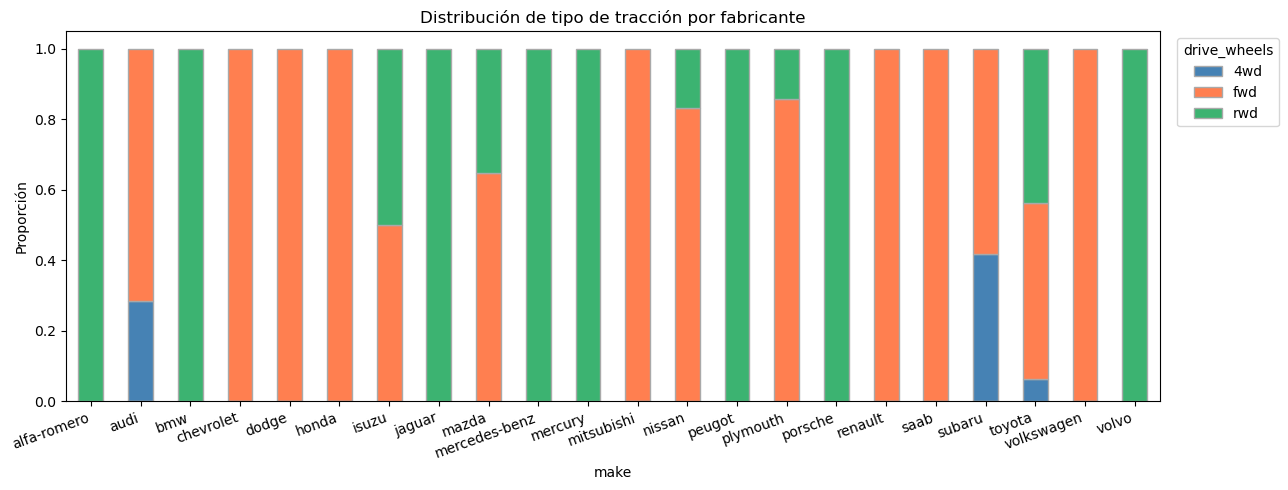

In [4]:
#Grafico de barras apilado---------
ct = pd.crosstab(cars_df.make, cars_df.drive_wheels, normalize = 'index')

ct.plot(kind = 'bar', stacked = True, figsize = (13, 5),
        color = ['steelblue', 'coral', 'mediumseagreen'], edgecolor = 'darkgray')

plt.ylabel('Proporción')
plt.title('Distribución de tipo de tracción por fabricante')
plt.legend(title = 'drive_wheels', bbox_to_anchor = (1.01, 1), loc='upper left')
plt.xticks(rotation = 20, ha = 'right')
plt.tight_layout()
plt.show()

**Comentario. Distribución de los tipos de tracción por cada fabricante.**  
* Los fabricantes más generalistas decantan por tracciones delanteras (`fwd`) lo que resulta en autos más simples mecánicamente. 
* También vemos que las marcas de lujo como Alfa Romeo, BMW, Jaguar, Mercedes-Benz tienden a tomar la tracción trasera (`rwd`) como su opción predilecta para brindar mejor dinamismo al manejar.
* Podemos ver que Audi, Subaru y Toyota también tienen sistemas de `4wd` las cuales son compañías que en algún momento corrieron en campeonatos de rally lo cual lo usan para mejorar la tracción en camino de grava y asfalto.
* El tipo de tracción está claramente asociado al posicionamiento de la marca.

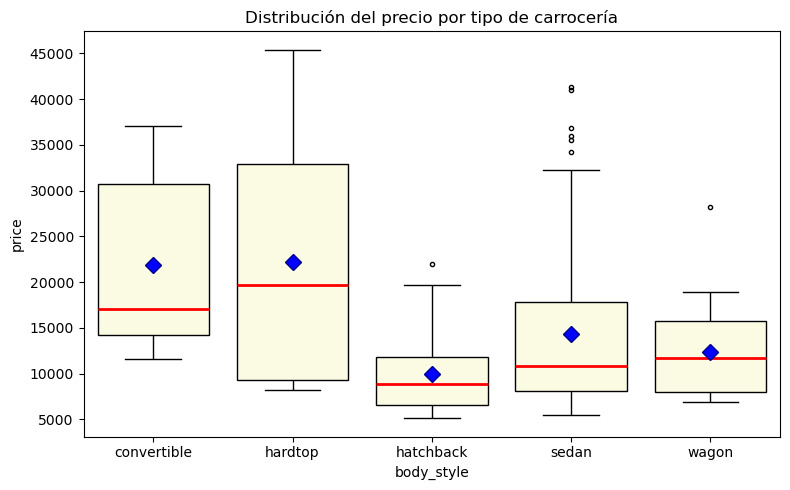

In [5]:
#Boxplots para variables numericas---------
fig, ax = plt.subplots(figsize = (8, 5))

sns.boxplot(x = 'body_style', y = 'price', data = cars_df, ax = ax, color = 'lightyellow', fliersize = 3, showmeans = True, linecolor = 'black', 
            medianprops={'color': 'red', 'linewidth': 2, 'linestyle': '-'}, 
            meanprops = {'marker': 'D', 'markerfacecolor': 'blue', 'markeredgecolor': 'darkblue', 'markersize': 8})

ax.set_title('Distribución del precio por tipo de carrocería')
plt.tight_layout()
plt.show()

**Comentario. Distribución del precio por tipo de carrocería.**  

* En este gráfico podemos comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Podemos ver los autos más económicos tienden a ser **hatchbacks** y **wagons**. 
* Los **sedanes** también comienzan con precios accesibles, pero podemos observar que se disparan rápidamente después del cuartil 3 donde probablemente estén los sedanes de lujo como **mercedes** o **bmw** con varios valores atípicos. 
* Los rangos de precios más altos se los llevan los **convertibles de tela** y los **hardtop**, lo más probable es que estos autos sean objetos de lujo con una mayor dispersión de precios.

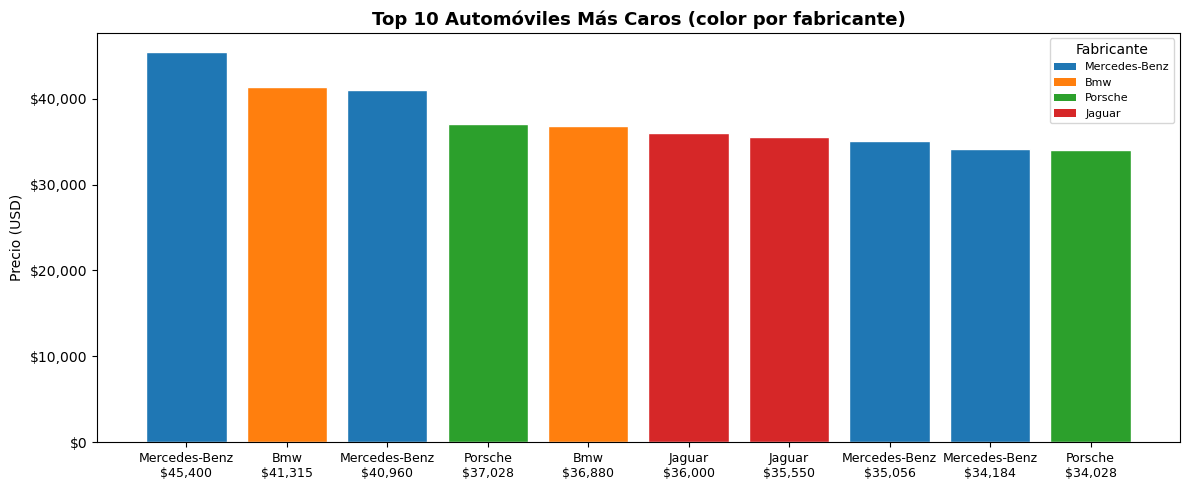

In [6]:
#Grafica de barra top automóviles mas caros---------
top10 = cars_df.nlargest(10, 'price')[['make','price']].sort_values('price', ascending=False)
palette_map = {m: c for m, c in zip(top10['make'].unique(),
               sns.color_palette('tab10', top10['make'].nunique()))}
bar_colors = [palette_map[m] for m in top10['make']]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top10)), top10['price'], color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(top10)))
ax.set_xticklabels([f"{r['make'].title()}\n${r['price']:,}"
                    for _, r in top10.iterrows()], fontsize=9)
ax.set_title('Top 10 Automóviles Más Caros (color por fabricante)',
             fontsize = 13, fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=m.title())
                   for m, c in palette_map.items()],
          title='Fabricante', loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

**Comentario. Top 10 de vehículos más caros, por marca.**
* Los 10 automóviles más caros están dominados por **Mercedes-Benz, BMW, Jaguar y Porsche**, con precios que superan los \$30,000 y llegan a \$45,400.
* Vemos que todos los autos son europeos, siendo en su mayoría alemanes (excepto Jaguar). 
* Esto confirma que el segmento de lujo está concentrado en pocas marcas y refuerza la relación entre fabricante y precio observada antes.

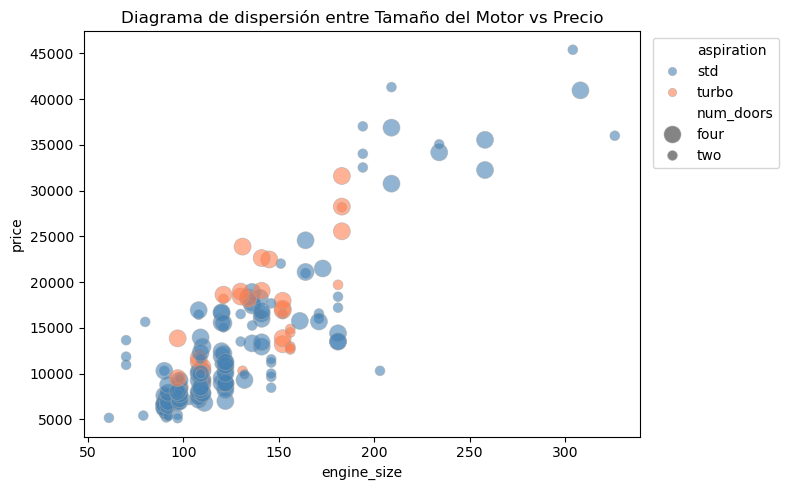

In [7]:
#Diagrama de dispersion---------
size_map = {'two': 50, 'four': 150}

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data = cars_df, x='engine_size', y = 'price',
                hue = 'aspiration',
                size = 'num_doors', sizes = size_map,
                palette = ['steelblue', 'coral'],
                alpha = 0.6, edgecolor = 'darkgray', ax = ax)

ax.set_title('Diagrama de dispersión entre Tamaño del Motor vs Precio')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Comentario. Diagrama de dispersión entre el tamaño del motor y el precio de los automóviles.**

* Existe correlación positiva clara entre tamaño del motor (`engine_size`) y precio (`price`).
* Podemos apreciar que los motores turbo cargados de la misma cilindrada que los aspirados naturalmente tienden a costar más debido a la complejidad de instalar un turbo además de requerir transmisiones que soporten la mayor cantidad de torque que ellos ofrecen. 
* Aun así, los autos con mayores precios son los que también tienen motores más grandes con aspiración natural, lo que va relacionado con los motores de autos lujosos europeos como **mercedes** y **bmw**. 
* También vemos que los autos con dos puertas tienden a tener motores grandes y precios altos, como lo vimos en la gráfica anterior puede ir relacionado con los modelos descapotables de tela o techo rígido ya que son modelos de lujo o deportividad alta.


4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

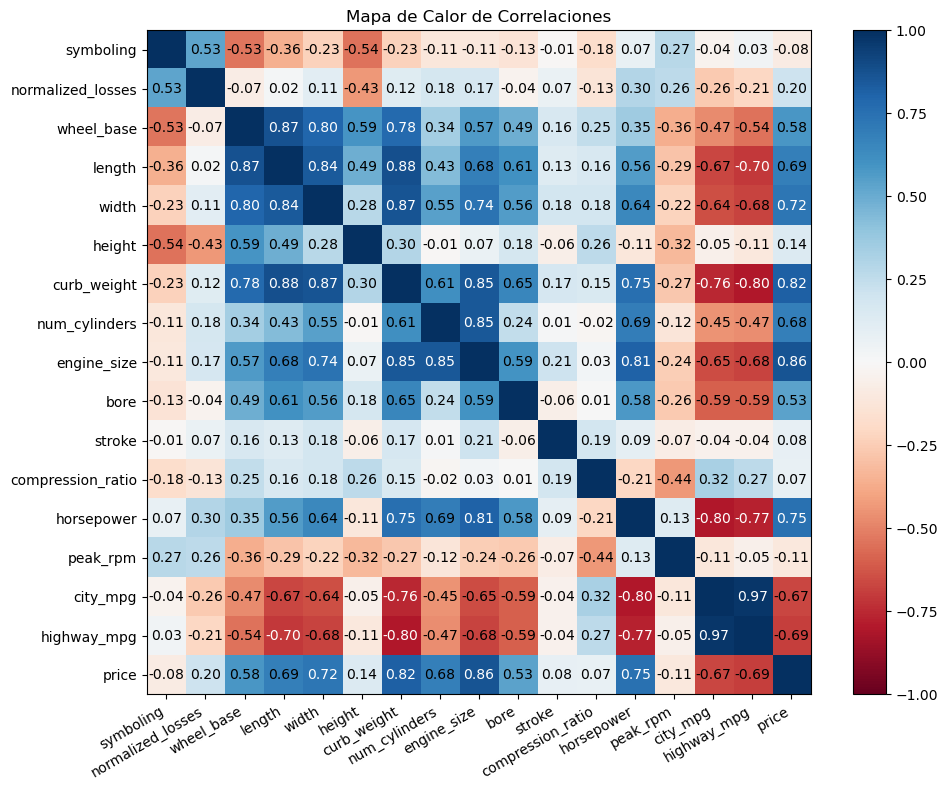


Variables con mayor correlación con precio:
  > engine_size: 0.86
  > curb_weight: 0.82
  > horsepower: 0.75


In [8]:
#Tomar solo columnas numericas y aplicar correlación de Pearson
Corr = cars_df[num_cols].corr(method = 'pearson')
nCorr = len(Corr.columns)

#Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

#Dibujar mapa de calor
im = ax.imshow(Corr, vmin = -1, vmax = 1, cmap = 'RdBu')

#Etiquetas
ax.set_xticks(range(nCorr))
ax.set_yticks(range(nCorr))

ax.set_xticklabels(Corr.columns, rotation = 30, ha = 'right')
ax.set_yticklabels(Corr.columns)

#Agregar valores
for i in range(nCorr):
    for j in range(nCorr):
        if i != j:
            TxtColor = 'white' if abs(Corr.iloc[i,j]) > 0.7 else 'black'
            ax.text(j, i, f'{Corr.iloc[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 10, color = TxtColor)

# Barra de colores
fig.colorbar(im)
ax.set_title('Mapa de Calor de Correlaciones')

fig.tight_layout()
plt.show()

print('\nVariables con mayor correlación con precio:')
top3 = Corr['price'].drop('price').abs().sort_values(ascending = False).head(3)

for var, corr in top3.items():
    print(f'  > {var}: {Corr['price'][var]:.2f}')

**Comentario:**  
En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad.
Especificamente, las variables más correlacionadas al precio fueron: `engine_size`, `curb_weight` y `horsepower`.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Aplica `SimpleImputer` sobre `X` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Realiza el escalamiento del conjunto `X` ya imputado, para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [9]:
y = cars_df['price'].copy()
X = cars_df[num_cols].drop(columns=["price"]).copy()


#Analisis de las variables con nulos
resumen = []
for col in ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm']:
    x = X[col].dropna()
    
    Q1, Q3 = x.quantile(0.25), x.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((x < Q1 - 1.5*IQR) | (x > Q3 + 1.5*IQR)).sum()
    
    resumen.append({'variable': col, 'nulos': X[col].isna().sum(), 'outliers': outliers, 'skew': Stat1.loc['skew', col], 'kurt': Stat1.loc['kurt', col]})

resumen_df = pd.DataFrame(resumen).set_index('variable')
print(resumen_df.round(2))

#Aplicamos mediana a las variables con muchos outliers o con alto sesgo y curtosis
imputer = SimpleImputer(strategy = 'median')
X[['stroke', 'horsepower']] = imputer.fit_transform(X[['stroke', 'horsepower']])

#Aplicamos media a todos los demas
imputer = SimpleImputer(strategy = 'mean')
X[['normalized_losses', 'bore', 'peak_rpm']] = imputer.fit_transform(X[['normalized_losses', 'bore', 'peak_rpm']])


#Escalado
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)
print('\nEstadísticas luego de escalado:')
X.describe().round(2).T[["mean", "std", "min", "max"]]


                   nulos  outliers  skew  kurt
variable                                      
normalized_losses     41         1  0.77  0.53
bore                   4         0  0.02 -0.83
stroke                 4        20 -0.68  2.07
horsepower             2         6  1.39  2.62
peak_rpm               2         2  0.07  0.06

Estadísticas luego de escalado:


,mean,std,min,max
symboling,0.0,1.0,-2.28,1.74
normalized_losses,-0.0,1.0,-1.80,4.24
wheel_base,-0.0,1.0,-2.02,3.69
length,0.0,1.0,-2.68,2.77
width,0.0,1.0,-2.62,2.99
height,-0.0,1.0,-2.43,2.49
curb_weight,0.0,1.0,-2.06,2.91
num_cylinders,-0.0,1.0,-2.21,7.07
engine_size,0.0,1.0,-1.59,4.79
bore,0.0,1.0,-2.92,2.26


**Comentario:**
* Se definió `price` como variable objetivo (`y`) y los **16 predictores numéricos** restantes como `X`. Por lo tanto, **PCA generará 16 componentes principales** (uno por cada variable de entrada, no conciderando `price`).
* La imputación se realizó con la **mediana** para las variables `stroke` y `horsepower`. Esto porque es **robusta** y ambas variables presentaron alto número de valores atípicos o distribuciones asimétricas, respectivamente. Evitando así el sesgo que introduciría la media.
* Para el resto de variables se utilizó la **media** (`normalized_losses`, `bore` y `peak_rpm`).
* Tras el escalamiento estándar, todas las variables tienen **media ≈ 0** y **desviación estándar = 1**, garantizando que contribuyan equitativamente al PCA.

6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.91,-2.46,-0.37,1.38,-1.89,-1.07,0.30,0.25,-1.06,-0.38,-0.46,0.29,-0.27,0.36,0.19,0.01
1,-0.91,-2.46,-0.37,1.38,-1.89,-1.07,0.30,0.25,-1.06,-0.38,-0.46,0.29,-0.27,0.36,0.19,0.01
2,0.64,-1.42,0.91,0.90,1.85,0.74,-0.61,1.29,-1.12,-1.03,0.53,0.64,0.19,-0.01,0.12,-0.11
3,-0.34,-0.92,0.44,-1.44,-0.27,0.84,-0.03,0.39,0.28,0.17,0.04,-0.03,-0.08,-0.39,0.01,0.05
4,1.19,-1.78,0.16,-1.04,0.14,0.87,-0.40,0.85,-0.02,-0.43,-0.07,-0.42,-0.05,0.08,-0.20,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,2.56,1.44,-1.53,-0.65,0.05,-0.22,0.73,-1.14,0.19,0.93,-0.18,-0.17,0.09,0.04,0.01,-0.04
201,3.30,0.89,-1.76,-0.57,0.14,-0.48,0.70,-0.97,0.07,0.48,0.36,0.32,0.49,-0.30,0.03,-0.03
202,3.66,0.53,-1.83,0.77,0.60,0.94,0.63,-0.48,-0.19,0.46,-0.41,-0.51,-0.00,-0.27,-0.02,-0.14
203,2.53,3.06,1.73,0.34,0.86,1.57,1.35,0.33,-1.49,-0.57,-0.17,-0.14,0.08,-0.22,-0.35,0.17


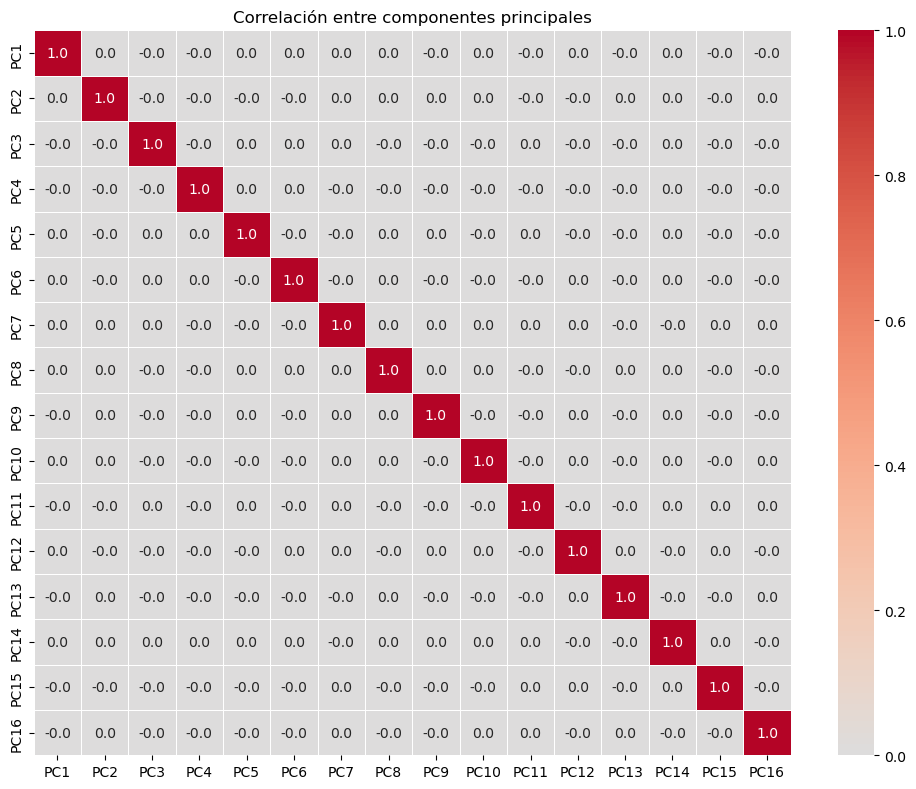

In [10]:
pca = PCA()
x_projected = pca.fit_transform(X)
cols_pca = [f'PC{i+1}' for i in range(x_projected.shape[1])]
x_projected = pd.DataFrame(x_projected, columns = cols_pca)
display(x_projected.round(2))

fig, ax = plt.subplots(figsize = (10, 8))
sns.heatmap(x_projected.corr().round(1), annot=True, fmt='.1f',
            cmap='coolwarm', center = 0, linewidths = 0.5, ax=ax)
ax.set_title('Correlación entre componentes principales')
plt.tight_layout()
plt.show()

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

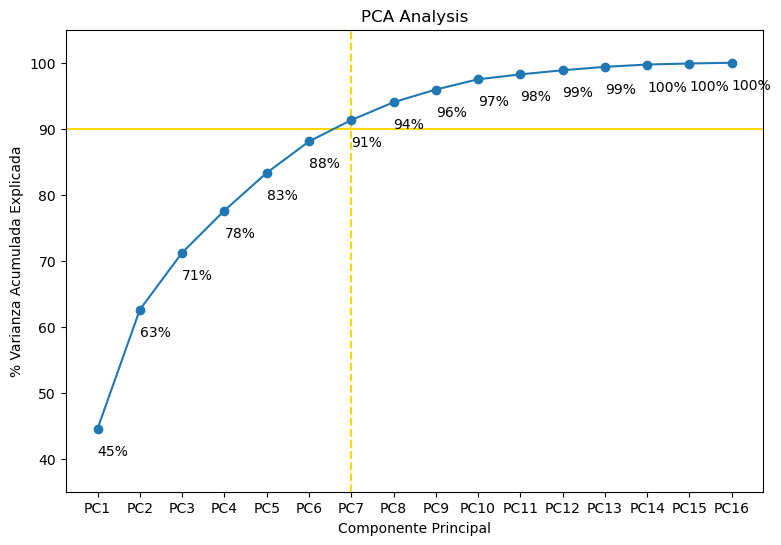

Componentes principales que explican al menos el 90% de la información: 7
  > Información acumulada CP1: 44.57%
  > Información acumulada CP2: 62.59%
  > Información acumulada CP3: 71.22%
  > Información acumulada CP4: 77.61%
  > Información acumulada CP5: 83.31%
  > Información acumulada CP6: 88.07%
  > Información acumulada CP7: 91.31%


In [11]:
total_components = X.shape[1]

fig, ax = plt.subplots(figsize = (9, 6))
ax.axhline(90, color = 'gold')
ax.axvline(6, color = 'gold', ls = '--')
ax.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker = 'o')
ax.set_title('PCA Analysis')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('% Varianza Acumulada Explicada')
ax.set_xticks(range(total_components))
ax.set_xticklabels(x_projected.columns)
ax.set_ylim([35, 105])

labels = np.cumsum(pca.explained_variance_ratio_)*100
for i in range(total_components):
  plt.text(i, labels[i] - 4,str(format(labels[i],'.0f'))+'%')
plt.show()

n = np.argmax(labels > 90) + 1
print(f'Componentes principales que explican al menos el 90% de la información: {n}')
for i in range(n):
  print(f'  > Información acumulada CP{i + 1}: {labels[i]:.2f}%')

**Comentario:**  
* El **PC1** explica alrededor del 45% y junto con el **PC2** esto sube al 63%.
* Se necesitan **7 componentes principales** para explicar **más del 90%** de la varianza total (acumulan **91.31%**).
* Esto significa que podemos **reducir de 16 variables a 7 componentes** perdiendo menos del 10% de la información, lo que simplifica notablemente el conjunto de datos.

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
PC1,0.10,0.03,0.30,0.34,0.33,0.11,0.36,0.25,0.33,0.26,0.05,0.02,0.30,0.09,0.31,0.32
PC2,0.40,0.34,0.27,0.14,0.06,0.42,0.02,0.11,0.08,0.00,0.03,0.36,0.27,0.36,0.24,0.19
PC3,0.26,0.31,0.03,0.04,0.11,0.28,0.08,0.18,0.20,0.14,0.51,0.49,0.01,0.26,0.20,0.19
PC4,0.07,0.30,0.22,0.19,0.09,0.18,0.02,0.56,0.29,0.04,0.46,0.01,0.16,0.30,0.17,0.16
PC5,0.38,0.35,0.00,0.08,0.01,0.02,0.04,0.27,0.12,0.39,0.54,0.24,0.11,0.34,0.02,0.02
PC6,0.14,0.50,0.19,0.09,0.11,0.23,0.02,0.32,0.04,0.50,0.38,0.11,0.08,0.29,0.10,0.07
PC7,0.09,0.32,0.11,0.02,0.14,0.03,0.06,0.07,0.07,0.16,0.14,0.61,0.23,0.61,0.04,0.05


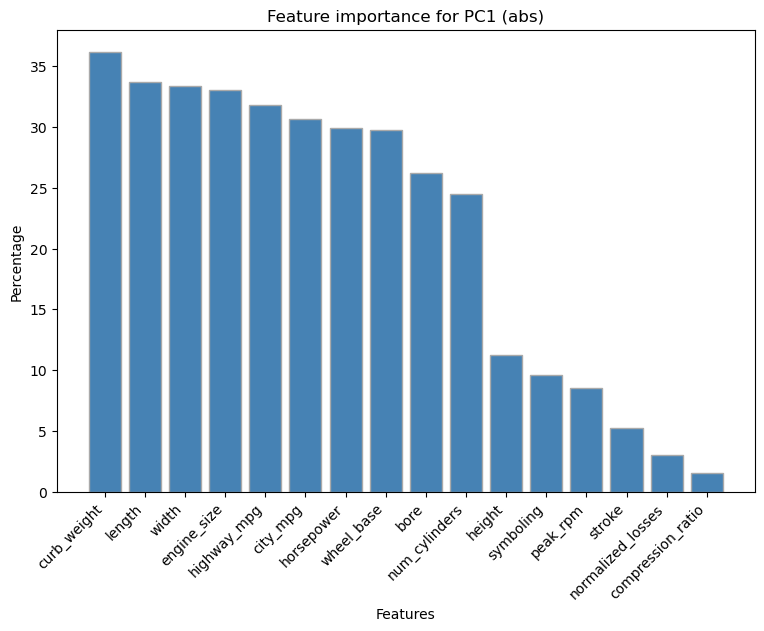

In [12]:
# Select the number of components
num_components = 7
pc_df = pd.DataFrame(abs(pca.components_[:num_components]), columns = X.columns, index=['PC{}'.format(i) for i in range(1, num_components + 1)])
display(pc_df.round(2))

#Grafica
sorted_vals = pc_df.iloc[0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(sorted_vals.index, sorted_vals*100, edgecolor='darkgray', color='steelblue')
ax.set_xlabel('Features')
ax.set_ylabel('Percentage')
ax.set_title('Feature importance for PC1 (abs)')
ax.set_xticks(range(len(sorted_vals)))
ax.set_xticklabels(sorted_vals.index, rotation=45, ha='right')

plt.show()

**Comentario:**  

* **PC1** está dominado por las variables: `curb_weight`, `engine_size`, `length`, `width`, `highway_mpg`, `city_mpg` y `horsepower`.
* En la gráfica se observa su impacto en **valor absoluto**, aunque algunas de estas tienen un impacto inversamente proporcional.

9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [13]:
# 10. OneHotEncoder para las categoricas restantes (drop='first')
print(f'Categoricas a codificar con One-Hot: {', '.join(cat_cols)}')

encoder = OneHotEncoder(drop = 'first')
ohe_array = encoder.fit_transform(cars_df[cat_cols]).toarray()
ohe_df = pd.DataFrame(ohe_array,
                      columns = encoder.get_feature_names_out(cat_cols),
                      index=cars_df.index)

display(ohe_df)


Categoricas a codificar con One-Hot: make, fuel_type, aspiration, num_doors, body_style, drive_wheels, engine_location, engine_type, fuel_system


,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [14]:
Data = pd.concat([y, x_projected.iloc[:, :7], ohe_df], axis = 1)
Data.to_csv('Data7.csv', index = False)
display(Data.round(2))

,price,PC1,PC2,PC3,PC4,PC5,PC6,PC7,make_audi,make_bmw,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,13495,-0.91,-2.46,-0.37,1.38,-1.89,-1.07,0.30,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,16500,-0.91,-2.46,-0.37,1.38,-1.89,-1.07,0.30,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,16500,0.64,-1.42,0.91,0.90,1.85,0.74,-0.61,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,13950,-0.34,-0.92,0.44,-1.44,-0.27,0.84,-0.03,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,17450,1.19,-1.78,0.16,-1.04,0.14,0.87,-0.40,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,16845,2.56,1.44,-1.53,-0.65,0.05,-0.22,0.73,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
201,19045,3.30,0.89,-1.76,-0.57,0.14,-0.48,0.70,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
202,21485,3.66,0.53,-1.83,0.77,0.60,0.94,0.63,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
203,22470,2.53,3.06,1.73,0.34,0.86,1.57,1.35,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


---

**Declaración de uso de IA**

*Anthropic. (2026). Claude Sonnet 4.6 [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://claude.ai/

---